In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd
data = pd.read_csv("Social_Network_Ads.csv")

In [4]:
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
x = data.iloc[:,[2,3]].values
y = data.iloc[:,4].values

In [6]:
y

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,

In [7]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x,y, train_size = 0.8, random_state = 42)

In [8]:
from sklearn.preprocessing import StandardScaler
sc_x = StandardScaler()
x_train = sc_x.fit_transform(x_train)
x_test = sc_x.transform(x_test)

In [9]:
from sklearn.linear_model import LogisticRegression 
classifier = LogisticRegression()
classifier.fit(x_train, y_train)
y_pred_train = classifier.predict(x_train)
y_pred_test = classifier.predict(x_test)

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, precision_score
cm = confusion_matrix (y_train, y_pred_train)
cm

array([[190,  15],
       [ 36,  79]])

In [11]:
tn, fp, fn, tp = cm.ravel()


In [12]:
accuracy_score(y_train, y_pred_train)

0.840625

In [13]:
recall_score(y_train, y_pred_train)

0.6869565217391305

In [14]:
precision_score(y_train, y_pred_train)

0.8404255319148937

C:\Users\FM\AppData\Local\Temp\ipykernel_21200\460452076.py:9: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter (X_Set [Y_Set == j, 0], X_Set [Y_Set == j,1],


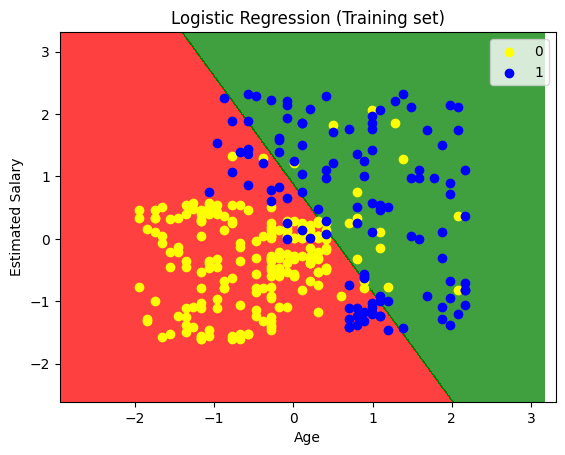

In [32]:
from matplotlib.colors import ListedColormap
X_Set, Y_Set = x_train, y_train
X1, X2 = np.meshgrid (np.arange(start = X_Set [:,0].min() -1, stop = X_Set[:, 0].max() +1, step = 0.01 ),
                      np.arange(start = X_Set [:,1].min() -1, stop = X_Set[:, 1].max() +1, step = 0.01 ))
plt.contourf (X1, X2, classifier.predict(np.array([X1.ravel (), X2. ravel ()]). T).reshape(X1. shape), alpha = 0.75, cmap = ListedColormap (('red', 'green')))
plt.xlim(X1.min(), X2.max())
plt.ylim (X2.min(), X2.max())
for i, j in enumerate (np.unique (Y_Set)):
     plt.scatter (X_Set [Y_Set == j, 0], X_Set [Y_Set == j,1],
             c = ListedColormap (('yellow', 'blue')) (i), label = j)
plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()